In [1]:
import duckdb
import pandas as pd

In [2]:
conn = duckdb.connect("../../duckdb/GCN4_final.db")
conn

In [3]:
def preview_db(db_name):
    return conn.execute(f"""
    SELECT *
    FROM "{db_name}"
    LIMIT 10
    """).fetchdf()

In [4]:
# This is the step 1 map after grouping, thresholding, and checking barcode exists
preview_db("step1_AD_AD_BC_RPTR_BC_unique_target")

,AD,AD_BC,RPTR_BC,count,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed
0,CCATTGTGTTCTCCTAAAGCTCCATCTGCTTTGATTACTCCAATGA...,AAAGTTATCAA,TTCGGTGCCATAAC,87,True,True,True,1
1,ATGTTTGAATTGGAAGCTGTTGAATCTGATCCACAAGGTTGGACTT...,AATCAATAATC,TGTGAAACAAAATG,87,True,True,True,0
2,TTTGATCCATCTAATGAAATTTCATTTGATGATCCAGTCTTGTTTC...,CAGTAACTATC,ATACGACGCTTTAC,87,True,True,True,1
3,TCTTCTTCTGTTCCATCTTCTGTTTCTAATATGGGTACTGTTTCTC...,GACCCCAACGT,CACCACGCTTAGCT,87,True,True,True,1
4,CCAACTTCTACTGCTACTACTAATTTGGCTTCTCCATTGTCTTTGT...,GGATCCAAGTT,ATGCGTATTATTTA,87,True,True,True,1
5,GCTGCTCATTACTTCTTGGCTTTGAGACAATCTCAAGAGTTCTCTG...,TCACTTGTTAT,CGAATGACTCGACC,87,True,True,True,1
6,GTTGCTACTGAATCTACTGATCCAATTTCTTTGAAGAGAGCTAAGA...,ATATTGTACTG,AAGGACCTACGAAC,87,True,True,True,1
7,AGGAAAGGTCCATTGCCAGCTATTATGGTTGATCCAAATGATAAAG...,GCCCATAACTC,CACCGGAATACCGG,87,True,True,True,1
8,GCTCAATTGTCTGCTGCTCCATTTAATCCAGATTTGTATAGAAGAC...,CTATGAATGGA,GAGTTCTATACTGC,87,True,True,True,0
9,GATGATATTGTTGATGTTGTTGGTGATTCTCCATCTACTTCTCCAA...,CTCTGTTGCAG,TGGATACTAACCTG,87,True,True,True,1


In [5]:
# This is the step 1 map after grouping, thresholding, and checking barcode exists
preview_db("step1_AD_AD_BC_RPTR_BC_grouped")

,AD,AD_BC,RPTR_BC,count,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed
0,CCATTGATAATTCTAGAATTGCTGTTCCATCTCAAAGAAGACATTC...,TCCTGAGCTAC,CTAGGTTAAAAGTA,14633,True,True,True,0
1,CAACAAACTCAACCATTGCCAGAATTGGTTCAACCAGTTCAACCAA...,GCTAAGGCGTA,TGCAGGAGCCACTC,9839,True,True,True,1
2,GTTTCTCCATTTATTGGTGATAATCAAGATTTGGATCAAGCTTTGT...,TTGCCCATCGT,ATTTTGTATAACGG,9458,True,True,True,0
3,TTGGAAAGAAATGGTGCTAAGATTCAATTATAGAAGATGTTCTTTG...,CGCGGGAATAG,AGTTTTCGGGGATA,7614,True,True,True,0
4,AATAATTTGCCATCTGATTGGTTGTGTTCTGGTAATGGTGGTAATA...,AAGAGCCGGTA,GGGGTTAAGTTGAA,5777,True,True,True,1
5,GATCAAGCTTTGTCTGGTGATCCATGGTATCCATTGTTTCCACAAG...,TGTACCTACAT,GCAACTAACCATTT,4918,True,True,True,1
6,AAACAAATTCATGTTGAACCAGAATTGGGTTCTGCTTTGCCAATGG...,ATGTTGATTAT,GCTTGGAAGATGGC,4881,True,True,True,0
7,TCTTCTCCAGCTGTTCCAACTGTCTTTGACTTTAATTCTGCTTCTT...,GGATACCCGGA,TTGTAAGTATTTTG,4605,True,True,True,0
8,GCTTTGAATCATAGATTGCAATTTGATCCAGCTTCTAAATTGAATA...,CGCCGACAAGA,AGGAAAGCGGGGCT,4045,True,True,True,0
9,TTGTTTCCACCAGAAGATCAATTTGAAGTTCCTAAGATTGAAGATT...,CGAAGAATAAT,GAGTCATTAATTTC,3783,True,True,True,1


In [6]:
# Filter to AD lenght is zero
conn.execute("""
SELECT *
FROM step1_AD_AD_BC_RPTR_BC_grouped
WHERE length(AD) = 0
LIMIT 3
""").fetchdf()

,AD,AD_BC,RPTR_BC,count,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed


In [7]:
# Filter to AD BC and RPTR BC correct length
conn.execute("""
CREATE or REPLACE TABLE step1_bonus_mutants AS
SELECT *
FROM "step1_AD_AD_BC_RPTR_BC_unique_target"
WHERE length(AD_BC) = 11
  AND length(RPTR_BC) = 14
""")
preview_db("step1_bonus_mutants")

,AD,AD_BC,RPTR_BC,count,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed
0,CCATTGTGTTCTCCTAAAGCTCCATCTGCTTTGATTACTCCAATGA...,AAAGTTATCAA,TTCGGTGCCATAAC,87,True,True,True,1
1,ATGTTTGAATTGGAAGCTGTTGAATCTGATCCACAAGGTTGGACTT...,AATCAATAATC,TGTGAAACAAAATG,87,True,True,True,0
2,TTTGATCCATCTAATGAAATTTCATTTGATGATCCAGTCTTGTTTC...,CAGTAACTATC,ATACGACGCTTTAC,87,True,True,True,1
3,TCTTCTTCTGTTCCATCTTCTGTTTCTAATATGGGTACTGTTTCTC...,GACCCCAACGT,CACCACGCTTAGCT,87,True,True,True,1
4,CCAACTTCTACTGCTACTACTAATTTGGCTTCTCCATTGTCTTTGT...,GGATCCAAGTT,ATGCGTATTATTTA,87,True,True,True,1
5,GCTGCTCATTACTTCTTGGCTTTGAGACAATCTCAAGAGTTCTCTG...,TCACTTGTTAT,CGAATGACTCGACC,87,True,True,True,1
6,GTTGCTACTGAATCTACTGATCCAATTTCTTTGAAGAGAGCTAAGA...,ATATTGTACTG,AAGGACCTACGAAC,87,True,True,True,1
7,AGGAAAGGTCCATTGCCAGCTATTATGGTTGATCCAAATGATAAAG...,GCCCATAACTC,CACCGGAATACCGG,87,True,True,True,1
8,GCTCAATTGTCTGCTGCTCCATTTAATCCAGATTTGTATAGAAGAC...,CTATGAATGGA,GAGTTCTATACTGC,87,True,True,True,0
9,GATGATATTGTTGATGTTGTTGGTGATTCTCCATCTACTTCTCCAA...,CTCTGTTGCAG,TGGATACTAACCTG,87,True,True,True,1


In [8]:
# Filter to not designed
conn.execute("""
CREATE OR REPLACE TABLE step1_bonus_mutants AS
SELECT *
FROM "step1_bonus_mutants"
WHERE Designed = 0
""")
preview_db("step1_bonus_mutants")

,AD,AD_BC,RPTR_BC,count,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed
0,ATGTTTGAATTGGAAGCTGTTGAATCTGATCCACAAGGTTGGACTT...,AATCAATAATC,TGTGAAACAAAATG,87,True,True,True,0
1,GCTCAATTGTCTGCTGCTCCATTTAATCCAGATTTGTATAGAAGAC...,CTATGAATGGA,GAGTTCTATACTGC,87,True,True,True,0
2,GCTAGGAAATTGGAAAGACAAGGTGAAATGGAAAGAATCTAAACAA...,TTGCCCACTCC,CCTCGCATGACGCA,87,True,True,True,0
3,TTGTTGACTCAATTGTTCTTGCCACCAACTTCTAAGATCTTGTCTA...,TACAGATTGAC,AAACTCACCAGATA,87,True,True,True,0
4,GGTGAATTGTCTTGTCATTTGCCAACTGCTGGTGCTCATGTTACTG...,CAAGTATTTTA,CCAACGCCAGTCCT,87,True,True,True,0
5,TCTACTGATTCTACTCCAGCTGCTGAAGCTGAGAATGCTGAAGATA...,CAGTACGAACG,GACCGTTCTCAGAC,87,True,True,True,0
6,TCTTCTTTGTTGTCTCAAAGAAGACATTCTTCTCATTTGCAATATA...,CCCCGCCGCTG,TTTATAGGGACTGA,87,True,True,True,0
7,AGAAATACTTTGGCTGCTAGAGAATCTAGACAAAGGAAATTTGATC...,CAAAATAAACA,CAGAAGTTCCATAT,87,True,True,True,0
8,GGTCAAGCTTGGCTGGTGATCCATGGTATCCATTGTTTCCACAAGA...,AGGGACTGACT,ACGTGAGATATAGT,87,True,True,True,0
9,GCATTTGGTGGATTTGCTGCTTCTATGTCTGGTAATCAATGCCATT...,AGCATCTTAAG,TAAGATAGGGAGCA,87,True,True,True,0


In [19]:
truncated_ADs = conn.execute("""
SELECT *,
       position('TGACTAG' IN AD) AS tgactag_index
FROM step1_bonus_mutants
WHERE position('TGACTAG' IN AD) > 0
""").fetchdf().sort_values(by = 'tgactag_index')
truncated_ADs

,AD,AD_BC,RPTR_BC,count,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed,tgactag_index
8664,TTGACTAGAAATGCTCTGATTCTACTCATGCTAATTCTGAACATAA...,GCGGAGCGTAA,TGAAAAATAAGCTC,109,True,True,True,0,2
1047,TTGACTAGATTGTTGCATGCTAATAATCATAAGACTGATTCTGTTT...,AGAGCAAAAAT,AGTATATTTATCAA,53,True,True,True,0,2
7286,TTGACTAGATTGTTGCATGCTAATAATCATAAGACTGATTCTGTTT...,GACAAAGAATT,GAGTCCCAAAATAT,164,True,True,True,0,2
7421,TTGACTAGATTGTTGCATGCTAATAATCATAAGACTGATTCTGTTT...,GGCTATCACGT,CTGTGACGGTAGAG,159,True,True,True,0,2
6924,TTGACTAGAAATGCTCATGATTCTACTCATGCTAATTCTGAACATA...,GGACCCGTATA,AACAGAGGGCAGAC,179,True,True,True,0,2
...,...,...,...,...,...,...,...,...,...
9174,TATAATAGGAAACATAGATCTGCTCCATTGAATCCAATTGTTCCAG...,GCAAACGAATA,CTATGTGTAAGACG,90,True,True,True,0,114
9213,CCACCAAGATTCTTGTTTACTGTTACTATTTATCATACATTTAGAT...,CACACTACCAT,TGTTTGCTTTTCTG,89,True,True,True,0,114
9224,ACTGAAACTCCACCATCTGCTAGACATTCTTCTGTTTCTGTTACCC...,CTCTTTGTGTA,TGCATACTTTAGCT,88,True,True,True,0,114
9229,ACTGTAATGGTACTACTAGAATTATTTCTGCTGATTCATTCTTTCC...,GGAAGTGGGGA,GACTTCACCTCGAT,88,True,True,True,0,114


In [60]:
short_truncated_ADs = truncated_ADs[truncated_ADs["tgactag_index"] < 16]
short_truncated_ADs

,AD,AD_BC,RPTR_BC,count,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed,tgactag_index
8664,TTGACTAGAAATGCTCTGATTCTACTCATGCTAATTCTGAACATAA...,GCGGAGCGTAA,TGAAAAATAAGCTC,109,True,True,True,0,2
1047,TTGACTAGATTGTTGCATGCTAATAATCATAAGACTGATTCTGTTT...,AGAGCAAAAAT,AGTATATTTATCAA,53,True,True,True,0,2
7286,TTGACTAGATTGTTGCATGCTAATAATCATAAGACTGATTCTGTTT...,GACAAAGAATT,GAGTCCCAAAATAT,164,True,True,True,0,2
7421,TTGACTAGATTGTTGCATGCTAATAATCATAAGACTGATTCTGTTT...,GGCTATCACGT,CTGTGACGGTAGAG,159,True,True,True,0,2
6924,TTGACTAGAAATGCTCATGATTCTACTCATGCTAATTCTGAACATA...,GGACCCGTATA,AACAGAGGGCAGAC,179,True,True,True,0,2
8106,TTGACTAGAAATGCTCATGATTCTACTCATGCTAATTCTGAACATA...,ATAGTGGCAGA,AAATTTTACAACAC,131,True,True,True,0,2
581,TTGACTAGAAATGCTATGATTCTACTCATGCTAATTCTGAACATAA...,AGGTTTGCGAT,CAGTTTCCCTGTTG,67,True,True,True,0,2
577,TTGACTAGATTGTTGCATGCTAATAATCATAAGACTGATTCTGTTT...,CGTATAATTGC,CGCTTTTAAAACTC,67,True,True,True,0,2
3904,GCTTTGACTAGAGTGATTCTCCATTTATTAATGATTCATTTGAATG...,CACGCGCGTAA,AAACAATTAAGTCT,367,True,True,True,0,5
312,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5


In [61]:
import glob
import tqdm

In [62]:
# trebl_rptr_results = glob.glob("../../output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR*/*_simple_umi_counts.tsv")
# dfs = []
# for path in tqdm.tqdm(trebl_rptr_results):
#     df = pd.read_csv(path, sep = "\t")
#     df["path"] = path
#     dfs.append(df)
# trebl_rptr_results_df = pd.concat(dfs)
# trebl_rptr_results_df

In [63]:
conn.register("trebl_rptr_results_df", trebl_rptr_results_df)
conn.register("short_truncated_ADs", short_truncated_ADs)

In [64]:
merged_df = conn.execute("""
SELECT *
FROM trebl_rptr_results_df AS t
INNER JOIN short_truncated_ADs AS a
ON t.RPTR_BC = a.RPTR_BC
""").fetchdf()

merged_df

,RPTR_BC,count,path,AD,AD_BC,RPTR_BC_1,count_1,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed,tgactag_index
0,GCAGACACAGAAGC,73,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5
1,CGACTACCAGAGGA,34,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,AGAGCTTCTCATTTGACTAGAATGTTTAAACAAGCCCACCATCTCC...,CCCAAAATCCG,CGACTACCAGAGGA,127,True,True,True,0,14
2,CGACTACCAGAGGA,54,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,AGAGCTTCTCATTTGACTAGAATGTTTAAACAAGCCCACCATCTCC...,CCCAAAATCCG,CGACTACCAGAGGA,127,True,True,True,0,14
3,GCAGACACAGAAGC,49,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5
4,GCAGACACAGAAGC,207,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5
5,CGACTACCAGAGGA,82,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,AGAGCTTCTCATTTGACTAGAATGTTTAAACAAGCCCACCATCTCC...,CCCAAAATCCG,CGACTACCAGAGGA,127,True,True,True,0,14
6,GCAGACACAGAAGC,153,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5
7,CGACTACCAGAGGA,130,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,AGAGCTTCTCATTTGACTAGAATGTTTAAACAAGCCCACCATCTCC...,CCCAAAATCCG,CGACTACCAGAGGA,127,True,True,True,0,14
8,GCAGACACAGAAGC,139,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5
9,CGACTACCAGAGGA,83,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,AGAGCTTCTCATTTGACTAGAATGTTTAAACAAGCCCACCATCTCC...,CCCAAAATCCG,CGACTACCAGAGGA,127,True,True,True,0,14


In [65]:
merged_df["time"] = merged_df["path"].str.extract(r'RPTR_\d+_(\d+)').astype(int)
merged_df["rep"] = merged_df["path"].str.extract(r'RPTR_(\d+)_\d+').astype(int)
merged_df

,RPTR_BC,count,path,AD,AD_BC,RPTR_BC_1,count_1,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed,tgactag_index,time,rep
0,GCAGACACAGAAGC,73,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,10,1
1,CGACTACCAGAGGA,34,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,AGAGCTTCTCATTTGACTAGAATGTTTAAACAAGCCCACCATCTCC...,CCCAAAATCCG,CGACTACCAGAGGA,127,True,True,True,0,14,10,1
2,CGACTACCAGAGGA,54,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,AGAGCTTCTCATTTGACTAGAATGTTTAAACAAGCCCACCATCTCC...,CCCAAAATCCG,CGACTACCAGAGGA,127,True,True,True,0,14,10,3
3,GCAGACACAGAAGC,49,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,10,3
4,GCAGACACAGAAGC,207,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,180,1
5,CGACTACCAGAGGA,82,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,AGAGCTTCTCATTTGACTAGAATGTTTAAACAAGCCCACCATCTCC...,CCCAAAATCCG,CGACTACCAGAGGA,127,True,True,True,0,14,180,1
6,GCAGACACAGAAGC,153,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,240,1
7,CGACTACCAGAGGA,130,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,AGAGCTTCTCATTTGACTAGAATGTTTAAACAAGCCCACCATCTCC...,CCCAAAATCCG,CGACTACCAGAGGA,127,True,True,True,0,14,240,1
8,GCAGACACAGAAGC,139,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,240,3
9,CGACTACCAGAGGA,83,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,AGAGCTTCTCATTTGACTAGAATGTTTAAACAAGCCCACCATCTCC...,CCCAAAATCCG,CGACTACCAGAGGA,127,True,True,True,0,14,240,3


In [66]:
pd.DataFrame(merged_df[["time", "rep"]].value_counts()).sort_index()

count
time rep       
0    1        2
     2        2
     3        2
5    1        2
     2        2
     3        2
10   1        2
     2        2
     3        2
15   1        2
     2        2
     3        2
30   1        2
     2        2
     3        2
180  1        2
     2        2
     3        2
240  1        2
     2        3
     3        2

In [67]:
merged_df[(merged_df["time"] == 0) & (merged_df["rep"] == 1)]

,RPTR_BC,count,path,AD,AD_BC,RPTR_BC_1,count_1,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed,tgactag_index,time,rep
29,GCAGACACAGAAGC,60,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,0,1
30,CGACTACCAGAGGA,29,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,AGAGCTTCTCATTTGACTAGAATGTTTAAACAAGCCCACCATCTCC...,CCCAAAATCCG,CGACTACCAGAGGA,127,True,True,True,0,14,0,1


In [69]:
len5_ad = merged_df[merged_df["RPTR_BC"] == "GCAGACACAGAAGC"]
len5_ad

,RPTR_BC,count,path,AD,AD_BC,RPTR_BC_1,count_1,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed,tgactag_index,time,rep
0,GCAGACACAGAAGC,73,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,10,1
3,GCAGACACAGAAGC,49,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,10,3
4,GCAGACACAGAAGC,207,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,180,1
6,GCAGACACAGAAGC,153,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,240,1
8,GCAGACACAGAAGC,139,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,240,3
11,GCAGACACAGAAGC,63,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,15,1
13,GCAGACACAGAAGC,34,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,0,3
15,GCAGACACAGAAGC,71,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,15,3
17,GCAGACACAGAAGC,59,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,10,2
19,GCAGACACAGAAGC,119,../../output/GCN4/yeast_pool_C_umi/trebl_exper...,TTGATGACTAGACAATGGCTGGTAATGCTCCAATTGGTGGTGAAGG...,ATGCAGTGATT,GCAGACACAGAAGC,76,True,True,True,0,5,30,2


In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

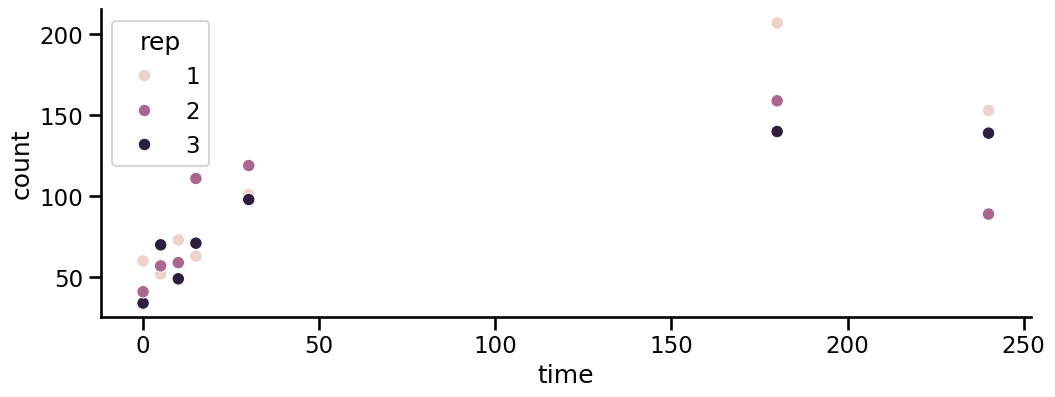

In [78]:
sns.set_context('talk')
plt.figure(figsize = (12,4))
ax = sns.scatterplot(data = len5_ad, x = "time", y = "count", hue = "rep")
# ax.set_xscale('log')
# ax.set_yscale('log')
sns.despine()

In [47]:
merged_df["path"].iloc[0]

'../../output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_3_30_S19_R1_001_fastp/RPTR_3_30_S19_R1_001_fastp_simple_umi_counts.tsv'

In [6]:
len("AAAGTTATCAA")

11

In [7]:
len("TGTGAAACAAAATG")

14